# Explora aquí

### Importar librerías y la URL. Detectar qué tabla ha de usar.

In [40]:
import os
import re
import sqlite3
from typing import Optional

import requests
import pandas as pd
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt

URL = "https://es.wikipedia.org/wiki/Anexo:Pel%C3%ADculas_con_las_mayores_recaudaciones"
HEADERS = {"User-Agent": "Mozilla/5.0"} # entrar como browser Mozilla
DB_PATH = "box_office.db"
TABLE_NAME = "peliculas_mas_taquilleras"

def to_number(x):
    """Convierte texto con símbolos de moneda a número entero (en USD).
    Mantiene NA si no puede convertir.
    """
    if pd.isna(x):
        return pd.NA
    s = str(x)
    # quitar todo lo que no sea dígito
    s = re.sub(r"[^\d]", "", s)
    return pd.to_numeric(s, errors="coerce")

def find_target_table(soup: BeautifulSoup) -> Optional[str]:
    # Buscar las tablas tipo wiki
    for t in soup.select("table.wikitable"):
        cap = t.find("caption") #Buscar el encabezado de la tabla.
        if cap:
            text = cap.get_text(strip=True).lower()
            # Busca algo relacionado con recaudaciones y mundo.
            if ("recaudaciones" in text or "recaudación" in text) and ("mundial" in text or "mundo" in text):
                return str(t)
    # Si no encontramos una tabla clara, agarra la primera.
    first = soup.select_one("table.wikitable")
    return str(first) if first else None

In [41]:
def main():
    resp = requests.get(URL, headers=HEADERS, timeout=30)
    resp.raise_for_status()

    soup = BeautifulSoup(resp.text, "html.parser")
    table_html = find_target_table(soup)
    if not table_html:
        raise RuntimeError("No encontré ninguna tabla.")
    df = pd.read_html(table_html, flavor="bs4")[0]

    # Normaliza encabezados
    df.columns = [str(c).strip() for c in df.columns]

    # localizador de columnas
    def pick(col_opts):
        for pattern in col_opts:
            for c in df.columns:
                if pattern in c.lower():
                    return c
        return None

    col_movie    = pick(["título","titulo","película","pelicula","film"])
    col_world    = pick(["recaudación mundial","recaudacion mundial","mundial","global"])
    col_domestic = pick(["ee. uu.","ee. uu","estados unidos"])
    col_foreign  = pick(["fuera de ee. uu.","fuera de ee. uu","internacional","resto del mundo"])
    col_year     = pick(["año de estreno","año","ano","estreno"])

    # Columnas monetarias a número
    money_like = []
    for c in df.columns:
        low = c.lower()
        if any(k in low for k in ["recaudación","recaudacion","taquilla","mundial","ee. uu","fuera"]):
            money_like.append(c)
    for c in money_like:
        df[c] = df[c].apply(to_number)

    # Tipado numérico (ranking/año)
    for name in df.columns:
        low = name.lower()
        if low in ("n.º","nº","n°","puesto","rango","posición","posicion"):
            df[name] = pd.to_numeric(df[name], errors="coerce", downcast="integer")
        if col_year and name == col_year:
            df[name] = pd.to_numeric(df[name], errors="coerce", downcast="integer")

    cols = {
        "movie": col_movie,
        "world": col_world,
        "domestic": col_domestic,
        "foreign": col_foreign,
        "year": col_year
    }

    return df, cols


### Visualizaciones

/tmp/ipykernel_4129/4284940600.py:9: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(table_html, flavor="bs4")[0]


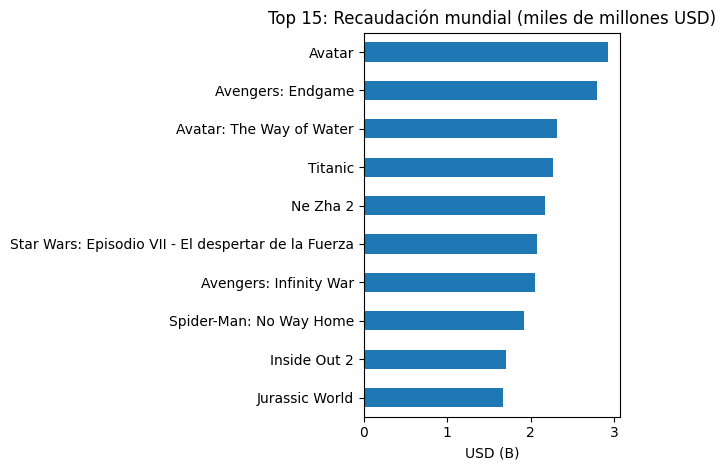

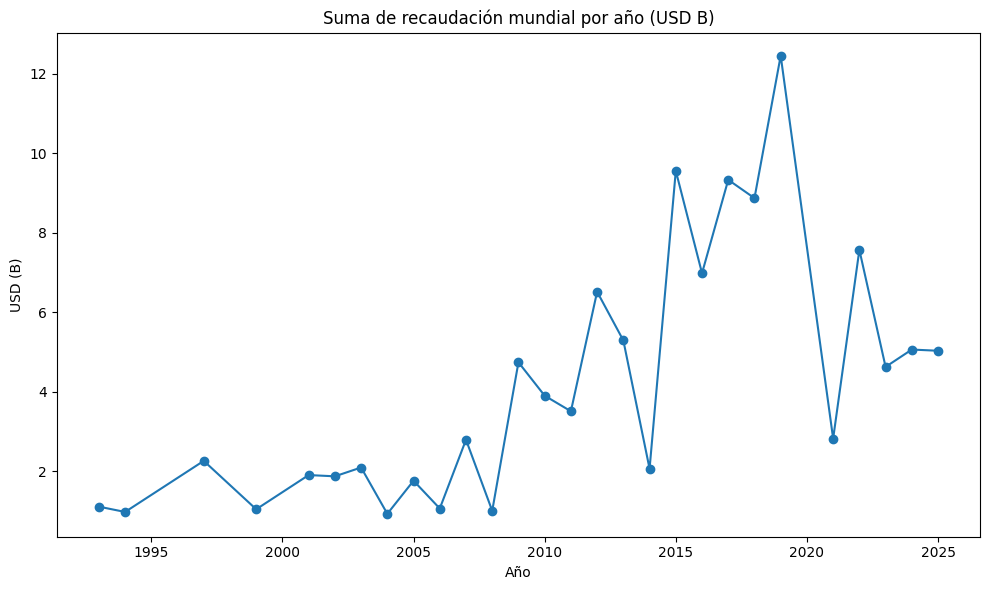

Filas cargadas: 100 | DB: box_office.db | Tabla: peliculas_mas_taquilleras


In [44]:
df, cols = main()
col_movie   = cols["movie"]
col_world   = cols["world"]
col_domestic= cols["domestic"]
col_foreign = cols["foreign"]
col_year    = cols["year"]


# Top 10 mundial
if col_world and col_movie:
    top = df[[col_movie, col_world]].dropna().copy()
    top[col_world] = top[col_world] / 1e9
    top = top.sort_values(col_world, ascending=False).head(10).set_index(col_movie)
    ax = top.iloc[::-1].plot(kind="barh", legend=False)  # no hace falta plt.figure + figsize aquí
    plt.title("Top 15: Recaudación mundial (miles de millones USD)")
    plt.xlabel("USD (B)")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

# Suma por año
if col_world and col_movie and col_year:
    by_year = (
        df[[col_year, col_world]].dropna()
        .groupby(col_year, as_index=False)[col_world].sum()
        .sort_values(col_year)
    )
    by_year[col_world] = by_year[col_world] / 1e9
    plt.figure(figsize=(10, 6))
    plt.plot(by_year[col_year], by_year[col_world], marker="o")
    plt.title("Suma de recaudación mundial por año (USD B)")
    plt.xlabel("Año")
    plt.ylabel("USD (B)")
    plt.tight_layout()
    plt.show()

# EE. UU. vs Internacional (stacked)
if col_domestic and col_foreign and col_movie:
    comp = df[[col_movie, col_domestic, col_foreign]].dropna().copy()
    comp[col_domestic] = comp[col_domestic] / 1e9
    comp[col_foreign]  = comp[col_foreign]  / 1e9
    comp["total"] = comp[col_domestic] + comp[col_foreign]             # ← CORRECCIÓN: suma de Series, no strings
    comp = comp.sort_values("total", ascending=False).head(10).set_index(col_movie)
    ax = comp.plot(kind="barh", stacked=True)
    plt.title("Top 10: Taquilla EE. UU. vs Fuera de EE. UU. (USD B)")
    plt.xlabel("USD (B)")
    plt.ylabel("")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

print(f"Filas cargadas: {len(df)} | DB: {DB_PATH} | Tabla: {TABLE_NAME}")
